In [ ]:
# Objective
1)Analyze historical pharmaceutical demand data.
2)Understand how demand changes over time.
3)Identify trends and possible weekly patterns in demand.
4)Build different forecasting models to predict future demand.
5)Compare ARIMA, SARIMA, and XGBoost models.
6)Evaluate the models using MAE, RMSE, and MAPE.
7)Select the model that gives the best prediction results.
8)Use the selected model to forecast future pharmaceutical demand.

In [ ]:
#Project Goals
1)Start with historical daily demand data.
2)Check the data for missing values and basic errors.
3)Explore demand using graphs and summary statistics.
4)Look at demand trends over time.
5)Calculate rolling averages to understand the general demand pattern.
6)Split the data into training and testing sets.
7)Check whether the data is stationary using the ADF test.
8)Use ACF and PACF to understand the relationship between past and current demand.
9)Then build ARIMA, SARIMA, and XGBoost models.

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [64]:
hourly = pd.read_csv("C:/Users/HP/Desktop/pharma_sales_hourly.csv")
daily = pd.read_csv("C:/Users/HP/Desktop/Pharma_sales_daily.csv")
weekly = pd.read_csv("C:/Users/HP/Desktop/pharma_sales_weekly.csv")
monthly = pd.read_csv("C:/Users/HP/Desktop/pharma_sales_monthly.csv")

print("HOURLY:", hourly.shape)
print("DAILY:", daily.shape)
print("WEEKLY:", weekly.shape)
print("MONTHLY:", monthly.shape)

print("\nHOURLY COLUMNS:")
print(hourly.columns.tolist())

print("\nDAILY COLUMNS:")
print(daily.columns.tolist())

print("\nWEEKLY COLUMNS:")
print(weekly.columns.tolist())

print("\nMONTHLY COLUMNS:")
print(monthly.columns.tolist())

HOURLY: (50532, 13)
DAILY: (2106, 13)
WEEKLY: (302, 9)
MONTHLY: (70, 9)

HOURLY COLUMNS:
['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06', 'Year', 'Month', 'Hour', 'Weekday Name']

DAILY COLUMNS:
['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06', 'Year', 'Month', 'Hour', 'Weekday Name']

WEEKLY COLUMNS:
['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

MONTHLY COLUMNS:
['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']


In [5]:
hourly.head(4)

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,01-02-2014 08:00,0.0,0.67,0.4,2.0,0.0,0.0,0.0,1.0,2014,1,8,Thursday
1,01-02-2014 09:00,0.0,0.00,1.0,0.0,2.0,0.0,0.0,0.0,2014,1,9,Thursday
2,01-02-2014 10:00,0.0,0.00,0.0,3.0,2.0,0.0,0.0,0.0,2014,1,10,Thursday
3,01-02-2014 11:00,0.0,0.00,0.0,2.0,1.0,0.0,0.0,0.0,2014,1,11,Thursday


In [3]:
hourly.shape

(50532, 13)

In [4]:
hourly.columns

Index(['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03',
       'R06', 'Year', 'Month', 'Hour', 'Weekday Name'],
      dtype='str')

In [5]:
daily.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,01-02-2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,01-03-2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,01-04-2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,01-05-2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,01-06-2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [10]:
daily.shape

(2106, 13)

In [6]:
weekly.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,01-05-2014,14.00,11.67,21.3,185.95,41.0,0.0,32.0,7.0
1,01-12-2014,29.33,12.68,37.9,190.70,88.0,5.0,21.0,7.2
2,1/19/2014,30.67,26.34,45.9,218.40,80.0,8.0,29.0,12.0
3,1/26/2014,34.00,32.37,31.5,179.60,80.0,8.0,23.0,10.0
4,02-02-2014,31.02,23.35,20.7,159.88,84.0,12.0,29.0,12.0


In [12]:
weekly.shape

(302, 9)

In [13]:
monthly.shape

(70, 9)

In [ ]:
## Checking Data Types

In [7]:
print("HOURLY")
print(hourly.dtypes)

print("\nDAILY")
print(daily.dtypes)

print("\nWEEKLY")
print(weekly.dtypes)

print("\nMONTHLY")
print(monthly.dtypes)

HOURLY
datum               str
M01AB           float64
M01AE           float64
N02BA           float64
N02BE           float64
N05B            float64
N05C            float64
R03             float64
R06             float64
Year              int64
Month             int64
Hour              int64
Weekday Name        str
dtype: object

DAILY
datum               str
M01AB           float64
M01AE           float64
N02BA           float64
N02BE           float64
N05B            float64
N05C            float64
R03             float64
R06             float64
Year              int64
Month             int64
Hour              int64
Weekday Name        str
dtype: object

WEEKLY
datum        str
M01AB    float64
M01AE    float64
N02BA    float64
N02BE    float64
N05B     float64
N05C     float64
R03      float64
R06      float64
dtype: object

MONTHLY
datum        str
M01AB    float64
M01AE    float64
N02BA    float64
N02BE    float64
N05B     float64
N05C       int64
R03      float64
R06      float

In [ ]:
## Checking Missing Values

In [8]:
print("HOURLY MISSING VALUES")
print(hourly.isnull().sum())

print("\nDAILY MISSING VALUES")
print(daily.isnull().sum())

print("\nWEEKLY MISSING VALUES")
print(weekly.isnull().sum())

print("\nMONTHLY MISSING VALUES")
print(monthly.isnull().sum())

HOURLY MISSING VALUES
datum           0
M01AB           0
M01AE           0
N02BA           0
N02BE           0
N05B            0
N05C            0
R03             0
R06             0
Year            0
Month           0
Hour            0
Weekday Name    0
dtype: int64

DAILY MISSING VALUES
datum           0
M01AB           0
M01AE           0
N02BA           0
N02BE           0
N05B            0
N05C            0
R03             0
R06             0
Year            0
Month           0
Hour            0
Weekday Name    0
dtype: int64

WEEKLY MISSING VALUES
datum    0
M01AB    0
M01AE    0
N02BA    0
N02BE    0
N05B     0
N05C     0
R03      0
R06      0
dtype: int64

MONTHLY MISSING VALUES
datum    0
M01AB    0
M01AE    0
N02BA    0
N02BE    0
N05B     0
N05C     0
R03      0
R06      0
dtype: int64


In [ ]:
## Checking Duplicates

In [9]:
print("Hourly duplicate dates:", hourly["datum"].duplicated().sum())
print("Daily duplicate dates:", daily["datum"].duplicated().sum())
print("Weekly duplicate dates:", weekly["datum"].duplicated().sum())
print("Monthly duplicate dates:", monthly["datum"].duplicated().sum())

Hourly duplicate dates: 0
Daily duplicate dates: 0
Weekly duplicate dates: 0
Monthly duplicate dates: 0


In [ ]:
## Coverting Dates from str to datetime

In [10]:
hourly["datum"] = pd.to_datetime(hourly["datum"], format="mixed")
daily["datum"] = pd.to_datetime(daily["datum"], format="mixed")
weekly["datum"] = pd.to_datetime(weekly["datum"], format="mixed")
monthly["datum"] = pd.to_datetime(monthly["datum"], format="mixed")

In [25]:
print("Hourly:", hourly["datum"].dtype)
print("Daily:", daily["datum"].dtype)
print("Weekly:", weekly["datum"].dtype)
print("Monthly:", monthly["datum"].dtype)

Hourly: datetime64[us]
Daily: datetime64[us]
Weekly: datetime64[us]
Monthly: datetime64[us]


In [11]:
print(hourly["datum"].min(), hourly["datum"].max())
print(daily["datum"].min(), daily["datum"].max())
print(weekly["datum"].min(), weekly["datum"].max())
print(monthly["datum"].min(), monthly["datum"].max())

2014-01-02 08:00:00 2019-10-08 19:00:00
2014-01-02 00:00:00 2019-10-08 00:00:00
2014-01-05 00:00:00 2019-10-13 00:00:00
2014-01-31 00:00:00 2019-10-31 00:00:00


In [12]:
drug_cols = [
    "M01AB",
    "M01AE",
    "N02BA",
    "N02BE",
    "N05B",
    "N05C",
    "R03",
    "R06"
]

daily["total_demand"] = daily[drug_cols].sum(axis=1)

print(daily.columns.tolist())

['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06', 'Year', 'Month', 'Hour', 'Weekday Name', 'total_demand']


In [13]:
daily[drug_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
M01AB,2106.0,5.033683,2.737579,0.0,3.00,4.99,6.670,17.340000
M01AE,2106.0,3.895830,2.133337,0.0,2.34,3.67,5.138,14.463000
N02BA,2106.0,3.880441,2.384010,0.0,2.00,3.50,5.200,16.000000
N02BE,2106.0,29.917095,15.590966,0.0,19.00,26.90,38.300,161.000000
N05B,2106.0,8.853627,5.605605,0.0,5.00,8.00,12.000,54.833333
N05C,2106.0,0.593522,1.092988,0.0,0.00,0.00,1.000,9.000000
R03,2106.0,5.512262,6.428736,0.0,1.00,4.00,8.000,45.000000
R06,2106.0,2.900198,2.415816,0.0,1.00,2.00,4.000,15.000000


In [8]:
daily[["datum", "total_demand"]].head(10)

,datum,total_demand
0,01-02-2014,48.47
1,01-03-2014,107.00
2,01-04-2014,91.35
3,01-05-2014,66.10
4,01-06-2014,58.20
5,01-07-2014,0.00
6,01-08-2014,75.23
7,01-09-2014,62.68
8,01-10-2014,81.30
9,01-11-2014,87.24


In [14]:
daily["total_demand"].describe()

count    2106.000000
mean       60.586659
std        21.561684
min         0.000000
25%        46.446750
50%        58.466500
75%        72.814250
max       198.950000
Name: total_demand, dtype: float64

In [15]:
daily["rolling_30"] = (
    daily["total_demand"]
    .rolling(window=30)
    .mean()
)
daily["rolling_30"]

0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
          ...    
2101    63.855389
2102    64.023722
2103    64.865056
2104    65.419956
2105    65.945389
Name: rolling_30, Length: 2106, dtype: float64

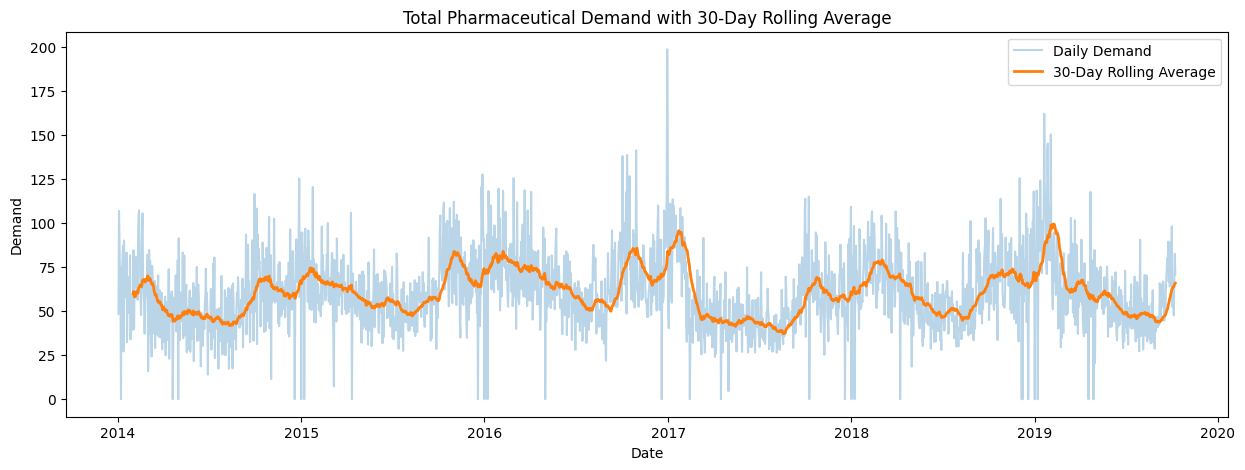

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(
    daily["datum"],
    daily["total_demand"],
    alpha=0.3,
    label="Daily Demand"
)

plt.plot(
    daily["datum"],
    daily["rolling_30"],
    linewidth=2,
    label="30-Day Rolling Average"
)

plt.title("Total Pharmaceutical Demand with 30-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()

plt.show()

In [17]:
daily.describe()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,total_demand,rolling_30
count,2106,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2077.000000
mean,2016-11-19 12:00:00,5.033683,3.895830,3.880441,29.917095,8.853627,0.593522,5.512262,2.900198,2016.401235,6.344255,275.945869,60.586659,60.503588
min,2014-01-02 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2014.000000,1.000000,190.000000,0.000000,37.254200
25%,2015-06-12 06:00:00,3.000000,2.340000,2.000000,19.000000,5.000000,0.000000,1.000000,1.000000,2015.000000,3.000000,276.000000,46.446750,49.935667
50%,2016-11-19 12:00:00,4.990000,3.670000,3.500000,26.900000,8.000000,0.000000,4.000000,2.000000,2016.000000,6.000000,276.000000,58.466500,59.727067
75%,2018-04-29 18:00:00,6.670000,5.138000,5.200000,38.300000,12.000000,1.000000,8.000000,4.000000,2018.000000,9.000000,276.000000,72.814250,68.601033
max,2019-10-08 00:00:00,17.340000,14.463000,16.000000,161.000000,54.833333,9.000000,45.000000,15.000000,2019.000000,12.000000,276.000000,198.950000,99.602500
std,NaN,2.737579,2.133337,2.384010,15.590966,5.605605,1.092988,6.428736,2.415816,1.665060,3.386954,1.970547,21.561684,12.272762


In [ ]:
## SEASONALITY ANALYSIS

# Monthly

In [18]:
Monthly_Seasonality = (
    daily.groupby("Month")["total_demand"].mean())
print(Monthly_Seasonality)

Month
1     75.517249
2     68.666086
3     61.094651
4     56.937322
5     53.365418
6     49.960339
7     47.088728
8     48.589308
9     61.115870
10    73.932667
11    63.562556
12    71.656213
Name: total_demand, dtype: float64


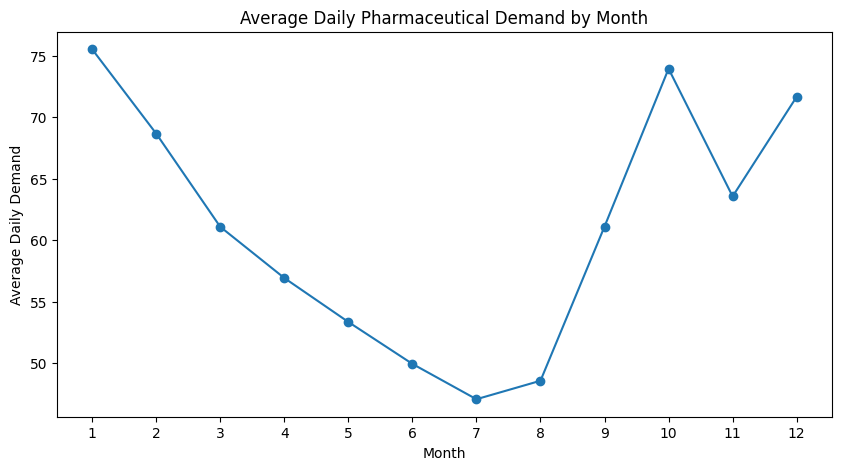

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    Monthly_Seasonality.index,
    Monthly_Seasonality.values,
    marker="o"
)

plt.title("Average Daily Pharmaceutical Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Demand")
plt.xticks(range(1, 13))

plt.show()

# Weekday 

In [20]:
Weekday_demand = (
    daily.groupby("Weekday Name")["total_demand"].mean()
        .reindex([
            "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

print(Weekday_demand)

Weekday Name
Monday       60.607364
Tuesday      60.017432
Wednesday    59.238425
Thursday     57.184018
Friday       60.247480
Saturday     65.673071
Sunday       61.134343
Name: total_demand, dtype: float64


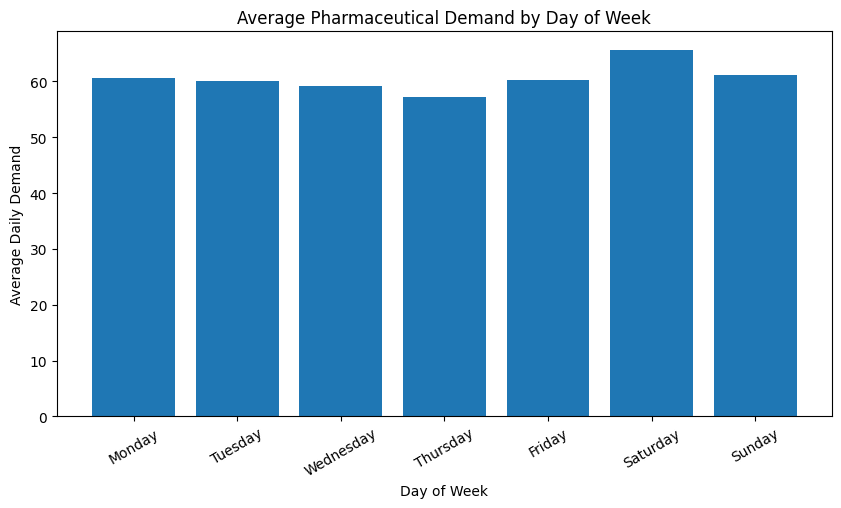

In [21]:
plt.figure(figsize=(10, 5))

plt.bar(
    Weekday_demand.index,
    Weekday_demand.values
)

plt.title("Average Pharmaceutical Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Daily Demand")

plt.xticks(rotation=30)

plt.show()

## Hourly

In [ ]:
## Create total hourly demand

In [22]:
hourly["total demand"] = hourly[drug_cols].sum(axis=1)

In [23]:
hourly["total demand"]

0         4.07
1         3.00
2         5.00
3         3.00
4         9.00
         ...  
50527    12.70
50528     3.33
50529     4.00
50530     9.00
50531    10.33
Name: total demand, Length: 50532, dtype: float64

In [ ]:
## average demand by hour

In [24]:
hourly_by_time = (
    hourly.groupby("Hour")["total demand"]
    .mean()
)

print(hourly_by_time)

Hour
0     0.000000
1     0.000000
2     0.000000
3     0.000000
4     0.000000
5     0.000000
6     0.000000
7     0.272004
8     2.868352
9     3.843552
10    4.554328
11    5.096845
12    5.007699
13    4.545759
14    4.169361
15    3.887425
16    3.728370
17    3.919423
18    4.782325
19    5.375953
20    5.325920
21    3.137042
22    0.076209
23    0.000277
Name: total demand, dtype: float64


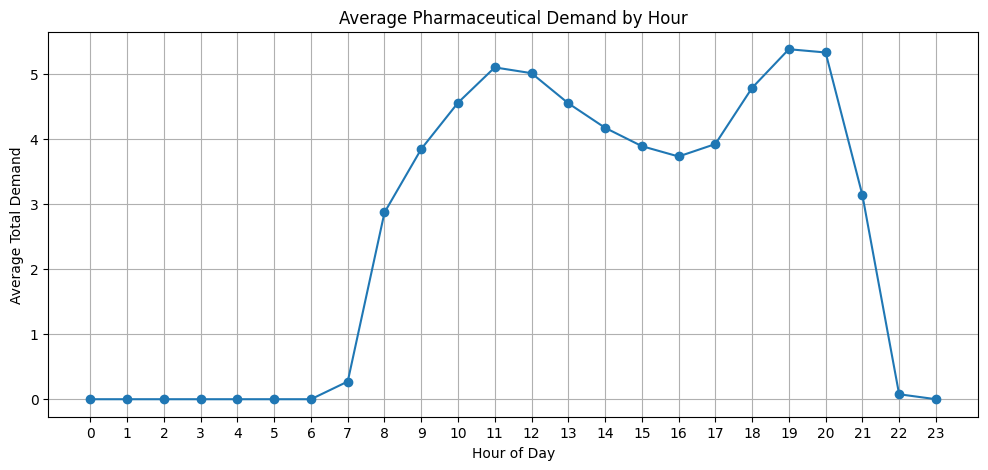

In [25]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_by_time.index,
    hourly_by_time.values,
    marker="o"
)

plt.title("Average Pharmaceutical Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Total Demand")

plt.xticks(range(24))
plt.grid(True)

plt.show()

## Validating the time-series structure

In [ ]:
## Checking for missing dates

In [26]:
daily = daily.sort_values("datum").reset_index(drop = True)

In [27]:
daily

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name,total_demand,rolling_30
0,2014-01-02,0.00,3.670,3.40,32.40,7.0,0.0,0.0,2.00,2014,1,248,Thursday,48.470,NaN
1,2014-01-03,8.00,4.000,4.40,50.60,16.0,0.0,20.0,4.00,2014,1,276,Friday,107.000,NaN
2,2014-01-04,2.00,1.000,6.50,61.85,10.0,0.0,9.0,1.00,2014,1,276,Saturday,91.350,NaN
3,2014-01-05,4.00,3.000,7.00,41.10,8.0,0.0,3.0,0.00,2014,1,276,Sunday,66.100,NaN
4,2014-01-06,5.00,1.000,4.50,21.70,16.0,2.0,6.0,2.00,2014,1,276,Monday,58.200,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2101,2019-10-04,7.34,5.683,2.25,22.45,13.0,0.0,1.0,1.00,2019,10,276,Friday,52.723,63.855389
2102,2019-10-05,3.84,5.010,6.00,25.40,7.0,0.0,0.0,0.33,2019,10,276,Saturday,47.580,64.023722
2103,2019-10-06,4.00,11.690,2.00,34.60,6.0,0.0,5.0,4.20,2019,10,276,Sunday,67.490,64.865056
2104,2019-10-07,7.34,4.507,3.00,50.80,6.0,0.0,10.0,1.00,2019,10,276,Monday,82.647,65.419956


In [28]:
print(daily["datum"].dtype)

datetime64[us]


In [29]:
daily["datum"] = pd.to_datetime(
    daily["datum"],
    format="mixed"
)

In [30]:
date_diff = daily["datum"].diff().dt.days

print(date_diff.value_counts().sort_index())

datum
1.0    2105
Name: count, dtype: int64


In [31]:
print(daily[["datum", "total_demand"]].head(15))

        datum  total_demand
0  2014-01-02         48.47
1  2014-01-03        107.00
2  2014-01-04         91.35
3  2014-01-05         66.10
4  2014-01-06         58.20
5  2014-01-07          0.00
6  2014-01-08         75.23
7  2014-01-09         62.68
8  2014-01-10         81.30
9  2014-01-11         87.24
10 2014-01-12         27.16
11 2014-01-13         90.20
12 2014-01-14         62.33
13 2014-01-15         58.04
14 2014-01-16         65.60


In [27]:
print(daily[["datum", "total_demand"]].tail(15))

          datum  total_demand
2091 2017-09-28        59.370
2092 2018-09-28        61.980
2093 2019-09-28        70.980
2094 2014-09-29        68.780
2095 2015-09-29        58.393
2096 2016-09-29        70.130
2097 2017-09-29        64.400
2098 2018-09-29        94.680
2099 2019-09-29        89.277
2100 2014-09-30       116.640
2101 2015-09-30        46.150
2102 2016-09-30        56.000
2103 2017-09-30       107.240
2104 2018-09-30        85.020
2105 2019-09-30        70.939


In [32]:
full_date_range = pd.date_range(
    start=daily["datum"].min(),
    end=daily["datum"].max(),
    freq="D"
)

missing_dates = full_date_range.difference(daily["datum"])

print("Number of missing dates:", len(missing_dates))
print(missing_dates[:20])

Number of missing dates: 0
DatetimeIndex([], dtype='datetime64[us]', freq='D')


In [33]:
print(weekly.head(5))

       datum  M01AB  M01AE  N02BA   N02BE  N05B  N05C   R03   R06
0 2014-01-05  14.00  11.67   21.3  185.95  41.0   0.0  32.0   7.0
1 2014-01-12  29.33  12.68   37.9  190.70  88.0   5.0  21.0   7.2
2 2014-01-19  30.67  26.34   45.9  218.40  80.0   8.0  29.0  12.0
3 2014-01-26  34.00  32.37   31.5  179.60  80.0   8.0  23.0  10.0
4 2014-02-02  31.02  23.35   20.7  159.88  84.0  12.0  29.0  12.0


In [34]:
print(weekly.tail(5))

         datum  M01AB   M01AE  N02BA    N02BE  N05B  N05C        R03    R06
297 2019-09-15  35.51  30.977  19.65  178.375  67.2   5.0  30.000000  30.50
298 2019-09-22  46.84  25.396  24.40  248.250  31.2   3.0  26.000000  21.00
299 2019-09-29  34.01  22.498  26.60  336.700  61.2   1.0  40.416667  23.10
300 2019-10-06  38.70  32.502  19.25  249.450  69.0   5.0  30.000000  12.13
301 2019-10-13   7.67   6.237   3.50   95.100  26.0   2.0  12.000000   1.00


In [ ]:
## Checking duplicate date

In [35]:
print("Duplicate dates:",daily["datum"].duplicated().sum())
print("Rows:",len(daily))
print("Unique dates:",daily["datum"].nunique())

Duplicate dates: 0
Rows: 2106
Unique dates: 2106


In [ ]:
## Total demand over time

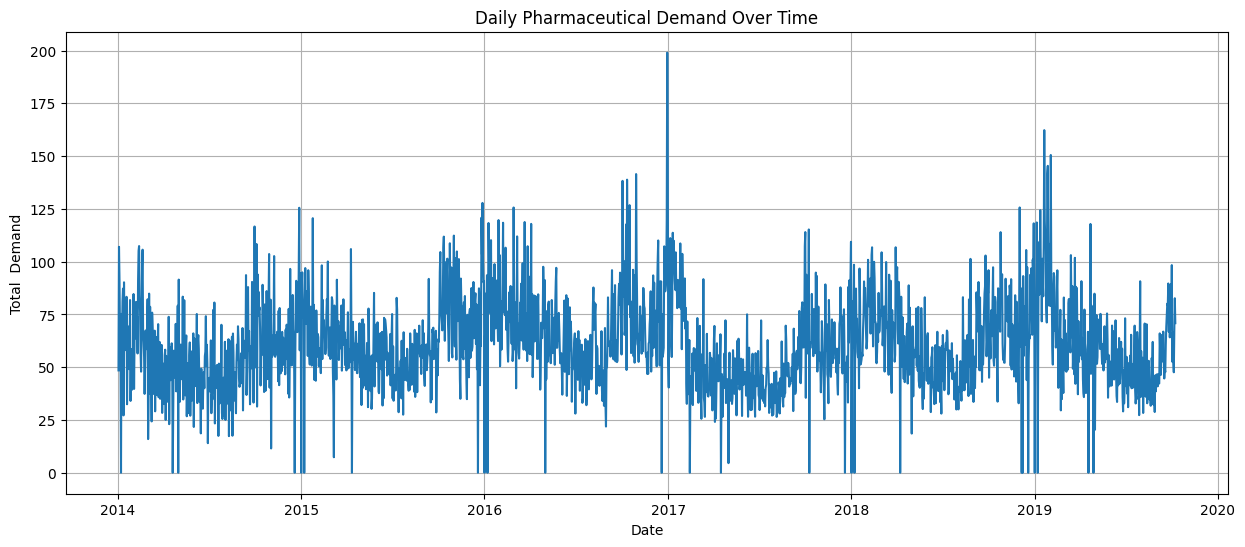

In [36]:
plt.figure(figsize=(15,6))

plt.plot(
    daily["datum"],
    daily["total_demand"]
        )
plt.title("Daily Pharmaceutical Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Total  Demand")

plt.grid(True)
plt.show()

In [ ]:
## 7-day rolling average.

In [38]:
daily["rolling_7"] = (
    daily["total_demand"]
    .rolling(window = 7)
    .mean())

In [48]:
daily["rolling_7"].head(20)

0           NaN
1           NaN
2           NaN
3           NaN
4           NaN
5           NaN
6     63.764286
7     65.794286
8     62.122857
9     61.535714
10    55.972857
11    60.544286
12    69.448571
13    66.992857
14    67.410000
15    64.135714
16    63.577143
17    64.330000
18    59.950000
19    60.951429
Name: rolling_7, dtype: float64

## Actual vs Rolling demand

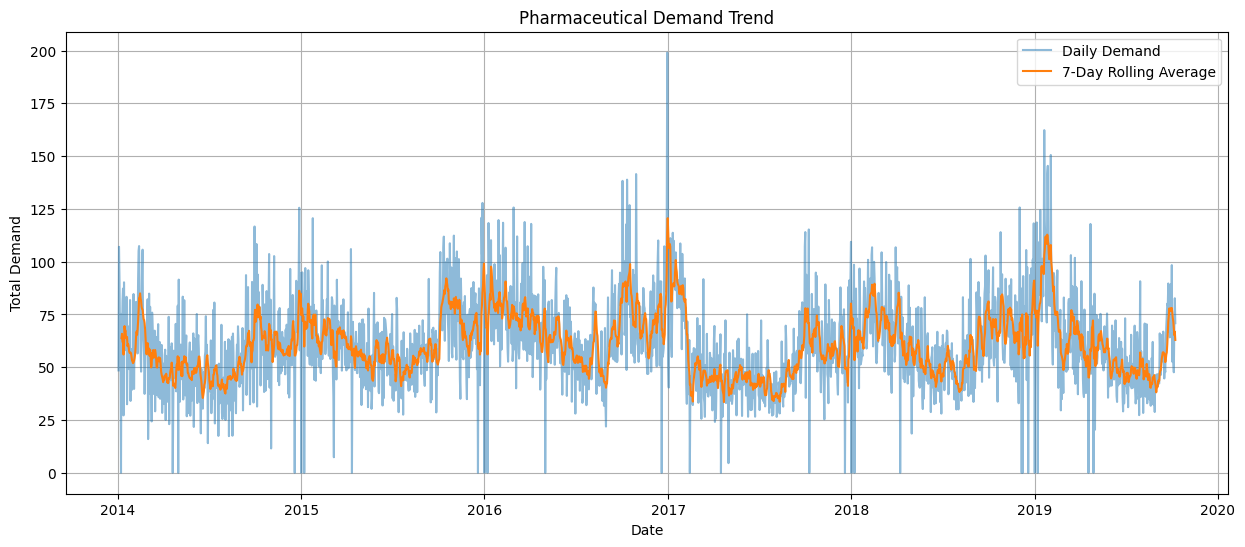

In [39]:
plt.figure(figsize=(15, 6))

plt.plot(
    daily["datum"],
    daily["total_demand"],
    label="Daily Demand",
    alpha=0.5
)

plt.plot(
    daily["datum"],
    daily["rolling_7"],
    label="7-Day Rolling Average"
)

plt.title("Pharmaceutical Demand Trend")
plt.xlabel("Date")
plt.ylabel("Total Demand")

plt.legend()
plt.grid(True)

plt.show()

## Train-Test Split

Since this is a time-series forecasting problem, the data is split chronologically rather than randomly.

The first 80% of observations are used for training the forecasting models, while the remaining 20% are reserved for testing model performance on unseen future observations.

In [40]:
# Create a clean time-series dataframe
ts = daily[["datum", "total_demand"]].copy()

# Set date as index
ts = ts.set_index("datum")

# Calculate the split point (80% training, 20% testing)
split_point = int(len(ts) * 0.80)

# Chronological train-test split
train = ts.iloc[:split_point]
test = ts.iloc[split_point:]

print("Total observations:", len(ts))
print("Training observations:", len(train))
print("Testing observations:", len(test))

print("\nTraining period:")
print(train.index.min(), "to", train.index.max())

print("\nTesting period:")
print(test.index.min(), "to", test.index.max())

Total observations: 2106
Training observations: 1684
Testing observations: 422

Training period:
2014-01-02 00:00:00 to 2018-08-12 00:00:00

Testing period:
2018-08-13 00:00:00 to 2019-10-08 00:00:00


In [ ]:
## ADF Test

In [42]:
adf_result = adfuller(train["total_demand"].dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

# Interpretation
if adf_result[1] <= 0.05:
    print("\nResult: The series is stationary.")
else:
    print("\nResult: The series is not stationary.")

ADF Statistic: -3.6105090998540392
p-value: 0.005563265629706972

Critical Values:
1%: -3.4342906911169404
5%: -2.8632805908715726
10%: -2.5676966486957706

Result: The series is stationary.


In [ ]:
## ACF and PACF plots

<Figure size 1200x500 with 0 Axes>

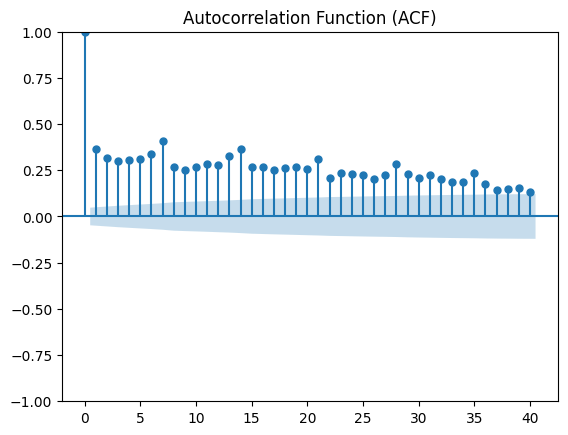

<Figure size 1200x500 with 0 Axes>

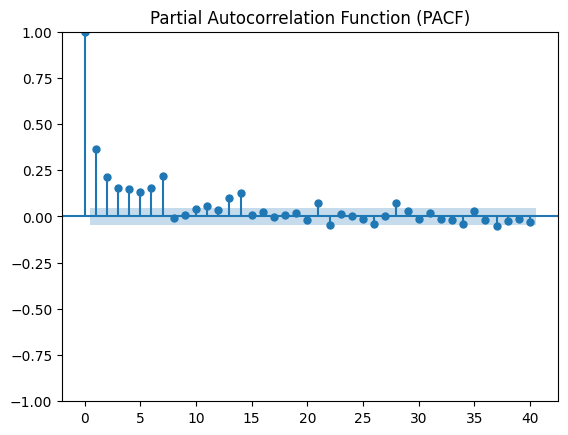

In [44]:
plt.figure(figsize=(12, 5))
plot_acf(train["total_demand"].dropna(), lags=40)
plt.title("Autocorrelation Function (ACF)")
plt.show()

# Create PACF plot
plt.figure(figsize=(12, 5))
plot_pacf(train["total_demand"].dropna(), lags=40, method="ywm")
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

In [ ]:
## candidate ARIMA models

In [45]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")
p_values = [0, 1, 2, 3]
q_values = [0, 1, 2, 3]
arima_results = []
for p in p_values:
    for q in q_values:
        
        try:
            model = ARIMA(
                train["total_demand"],
                order=(p, 0, q)
            )
            
            model_fit = model.fit()
            
            arima_results.append({
                "p": p,
                "d": 0,
                "q": q,
                "AIC": model_fit.aic,
                "BIC": model_fit.bic
            })
            
            print(f"ARIMA({p},0,{q}) fitted successfully")
            
        except Exception as e:
            print(f"ARIMA({p},0,{q}) failed: {e}")
arima_results_df = pd.DataFrame(arima_results)

# Sort models by AIC
arima_results_df = arima_results_df.sort_values("AIC").reset_index(drop=True)

print("\nARIMA Model Comparison:")
display(arima_results_df)

ARIMA(0,0,0) fitted successfully
ARIMA(0,0,1) fitted successfully
ARIMA(0,0,2) fitted successfully
ARIMA(0,0,3) fitted successfully
ARIMA(1,0,0) fitted successfully
ARIMA(1,0,1) fitted successfully
ARIMA(1,0,2) fitted successfully
ARIMA(1,0,3) fitted successfully
ARIMA(2,0,0) fitted successfully
ARIMA(2,0,1) fitted successfully
ARIMA(2,0,2) fitted successfully
ARIMA(2,0,3) fitted successfully
ARIMA(3,0,0) fitted successfully
ARIMA(3,0,1) fitted successfully
ARIMA(3,0,2) fitted successfully
ARIMA(3,0,3) fitted successfully

ARIMA Model Comparison:


,p,d,q,AIC,BIC
0,3,0,3,14533.302586,14576.734003
1,1,0,2,14537.883555,14565.028191
2,2,0,1,14538.029365,14565.174001
3,2,0,2,14538.571921,14571.145484
4,2,0,3,14539.229426,14577.231917
5,3,0,1,14539.239462,14571.813025
6,3,0,2,14539.247666,14577.250156
7,1,0,3,14539.485014,14572.058577
8,1,0,1,14539.600971,14561.316679
9,3,0,0,14705.038470,14732.183106


In [ ]:
## Testing ARIMA Model on test data

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Select top 5 ARIMA models based on AIC
top_arima_models = arima_results_df.head(5)

arima_test_results = []

for _, row in top_arima_models.iterrows():
    
    p = int(row["p"])
    d = int(row["d"])
    q = int(row["q"])
    
    # Fit model on training data
    model = ARIMA(
        train["total_demand"],
        order=(p, d, q)
    )
    
    model_fit = model.fit()
    
    # Forecast the complete test period
    forecast = model_fit.forecast(steps=len(test))
    
    # Calculate evaluation metrics
    mae = mean_absolute_error(
        test["total_demand"],
        forecast
    )
    
    rmse = np.sqrt(
        mean_squared_error(
            test["total_demand"],
            forecast
        )
    )
    
    # Avoid division by zero in MAPE
    actual = test["total_demand"].values
    predicted = np.array(forecast)
    
    non_zero = actual != 0
    
    mape = np.mean(
        np.abs(
            (actual[non_zero] - predicted[non_zero])
            / actual[non_zero]
        )
    ) * 100
    
    arima_test_results.append({
        "Model": f"ARIMA({p},{d},{q})",
        "AIC": row["AIC"],
        "BIC": row["BIC"],
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    })

# Create comparison table
arima_test_results_df = pd.DataFrame(arima_test_results)

# Sort by RMSE
arima_test_results_df = arima_test_results_df.sort_values(
    "RMSE"
).reset_index(drop=True)

print("ARIMA Test Set Performance:")
display(arima_test_results_df)

ARIMA Test Set Performance:


,Model,AIC,BIC,MAE,RMSE,MAPE (%)
0,"ARIMA(2,0,2)",14538.571921,14571.145484,17.980625,23.804714,27.479150
1,"ARIMA(3,0,3)",14533.302586,14576.734003,17.999107,23.830706,27.499708
2,"ARIMA(2,0,3)",14539.229426,14577.231917,18.014667,23.847125,27.514651
3,"ARIMA(1,0,2)",14537.883555,14565.028191,18.021487,23.854801,27.520617
4,"ARIMA(2,0,1)",14538.029365,14565.174001,18.025814,23.874597,27.458225


In [ ]:
## SARIMA Model

In [47]:
from statsmodels.tsa.statespace.sarimax import SARIMAX


warnings.filterwarnings("ignore")

# Candidate non-seasonal parameters
p_values = [1, 2, 3]
q_values = [1, 2, 3]

# Candidate seasonal parameters
P_values = [0, 1]
Q_values = [0, 1]

# We already established:
# d = 0
# D = 0
# Weekly seasonality = 7 days
d = 0
D = 0
seasonal_period = 7

sarima_results = []

# Test different SARIMA combinations
for p in p_values:
    for q in q_values:
        for P in P_values:
            for Q in Q_values:

                try:
                    model = SARIMAX(
                        train["total_demand"],
                        order=(p, d, q),
                        seasonal_order=(P, D, Q, seasonal_period),
                        enforce_stationarity=False,
                        enforce_invertibility=False
                    )

                    model_fit = model.fit(disp=False)

                    sarima_results.append({
                        "p": p,
                        "d": d,
                        "q": q,
                        "P": P,
                        "D": D,
                        "Q": Q,
                        "s": seasonal_period,
                        "AIC": model_fit.aic,
                        "BIC": model_fit.bic
                    })

                    print(
                        f"SARIMA({p},{d},{q})"
                        f"({P},{D},{Q},{seasonal_period}) fitted successfully"
                    )

                except Exception as e:
                    print(
                        f"SARIMA({p},{d},{q})"
                        f"({P},{D},{Q},{seasonal_period}) failed: {e}"
                    )

# Convert results to DataFrame
sarima_results_df = pd.DataFrame(sarima_results)

# Sort by AIC
sarima_results_df = sarima_results_df.sort_values(
    "AIC"
).reset_index(drop=True)

print("\nSARIMA Model Comparison:")
display(sarima_results_df)

SARIMA(1,0,1)(0,0,0,7) fitted successfully
SARIMA(1,0,1)(0,0,1,7) fitted successfully
SARIMA(1,0,1)(1,0,0,7) fitted successfully
SARIMA(1,0,1)(1,0,1,7) fitted successfully
SARIMA(1,0,2)(0,0,0,7) fitted successfully
SARIMA(1,0,2)(0,0,1,7) fitted successfully
SARIMA(1,0,2)(1,0,0,7) fitted successfully
SARIMA(1,0,2)(1,0,1,7) fitted successfully
SARIMA(1,0,3)(0,0,0,7) fitted successfully
SARIMA(1,0,3)(0,0,1,7) fitted successfully
SARIMA(1,0,3)(1,0,0,7) fitted successfully
SARIMA(1,0,3)(1,0,1,7) fitted successfully
SARIMA(2,0,1)(0,0,0,7) fitted successfully
SARIMA(2,0,1)(0,0,1,7) fitted successfully
SARIMA(2,0,1)(1,0,0,7) fitted successfully
SARIMA(2,0,1)(1,0,1,7) fitted successfully
SARIMA(2,0,2)(0,0,0,7) fitted successfully
SARIMA(2,0,2)(0,0,1,7) fitted successfully
SARIMA(2,0,2)(1,0,0,7) fitted successfully
SARIMA(2,0,2)(1,0,1,7) fitted successfully
SARIMA(2,0,3)(0,0,0,7) fitted successfully
SARIMA(2,0,3)(0,0,1,7) fitted successfully
SARIMA(2,0,3)(1,0,0,7) fitted successfully
SARIMA(2,0,

,p,d,q,P,D,Q,s,AIC,BIC
0,1,0,3,1,0,1,7,14343.429634,14381.386250
1,2,0,3,1,0,1,7,14345.377052,14388.756042
2,3,0,3,1,0,1,7,14347.276249,14396.077613
3,1,0,2,1,0,1,7,14349.388615,14381.926442
4,3,0,1,1,0,1,7,14351.254618,14389.215417
5,2,0,2,1,0,1,7,14352.472273,14390.433072
6,3,0,2,1,0,1,7,14354.436218,14397.819988
7,2,0,1,1,0,1,7,14362.589209,14395.130620
8,1,0,1,1,0,1,7,14368.233863,14395.351705
9,1,0,3,0,0,1,7,14405.662063,14438.196306


In [ ]:
## Testing Top 5 SARIMA Model

In [48]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

# Select top 5 SARIMA models based on AIC
top_sarima_models = sarima_results_df.head(5)

sarima_test_results = []

for _, row in top_sarima_models.iterrows():

    p = int(row["p"])
    d = int(row["d"])
    q = int(row["q"])

    P = int(row["P"])
    D = int(row["D"])
    Q = int(row["Q"])
    s = int(row["s"])

    # Fit SARIMA model on training data
    model = SARIMAX(
        train["total_demand"],
        order=(p, d, q),
        seasonal_order=(P, D, Q, s),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    model_fit = model.fit(disp=False)

    # Forecast the complete test period
    forecast = model_fit.forecast(steps=len(test))

    # Convert to arrays
    actual = test["total_demand"].values
    predicted = np.array(forecast)

    # MAE
    mae = mean_absolute_error(actual, predicted)

    # RMSE
    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    # MAPE
    non_zero = actual != 0

    mape = np.mean(
        np.abs(
            (actual[non_zero] - predicted[non_zero])
            / actual[non_zero]
        )
    ) * 100

    sarima_test_results.append({
        "Model": f"SARIMA({p},{d},{q})({P},{D},{Q},{s})",
        "AIC": row["AIC"],
        "BIC": row["BIC"],
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    })

# Create comparison DataFrame
sarima_test_results_df = pd.DataFrame(
    sarima_test_results
)

# Sort by RMSE
sarima_test_results_df = sarima_test_results_df.sort_values(
    "RMSE"
).reset_index(drop=True)

print("SARIMA Test Set Performance:")
display(sarima_test_results_df)

SARIMA Test Set Performance:


,Model,AIC,BIC,MAE,RMSE,MAPE (%)
0,"SARIMA(1,0,3)(1,0,1,7)",14343.429634,14381.386250,33.819279,39.273078,49.227714
1,"SARIMA(3,0,1)(1,0,1,7)",14351.254618,14389.215417,33.832770,39.285307,49.252074
2,"SARIMA(1,0,2)(1,0,1,7)",14349.388615,14381.926442,33.842197,39.293604,49.269816
3,"SARIMA(2,0,3)(1,0,1,7)",14345.377052,14388.756042,33.921441,39.364300,49.416308
4,"SARIMA(3,0,3)(1,0,1,7)",14347.276249,14396.077613,33.993679,39.429662,49.547687


In [ ]:
## XCBosst Feature Engineering

In [49]:
# Create a clean dataframe
xgb_df = daily[["datum", "total_demand"]].copy()

# Set date as index
xgb_df["datum"] = pd.to_datetime(xgb_df["datum"])
xgb_df = xgb_df.set_index("datum")

# Lag Features
xgb_df["lag_1"] = xgb_df["total_demand"].shift(1)
xgb_df["lag_2"] = xgb_df["total_demand"].shift(2)
xgb_df["lag_3"] = xgb_df["total_demand"].shift(3)

# Weekly lags
xgb_df["lag_7"] = xgb_df["total_demand"].shift(7)
xgb_df["lag_14"] = xgb_df["total_demand"].shift(14)

# Approximately one month ago
xgb_df["lag_30"] = xgb_df["total_demand"].shift(30)

# Rolling Features

xgb_df["rolling_mean_7"] = (
    xgb_df["total_demand"]
    .shift(1)
    .rolling(window=7)
    .mean()
)

xgb_df["rolling_mean_14"] = (
    xgb_df["total_demand"]
    .shift(1)
    .rolling(window=14)
    .mean()
)

xgb_df["rolling_mean_30"] = (
    xgb_df["total_demand"]
    .shift(1)
    .rolling(window=30)
    .mean()
)


# Calendar Features
xgb_df["day_of_week"] = xgb_df.index.dayofweek
xgb_df["month"] = xgb_df.index.month
xgb_df["year"] = xgb_df.index.year

# Remove rows with missing
# lag/rolling values

xgb_df = xgb_df.dropna()

# Display the resulting data
print("XGBoost dataset shape:", xgb_df.shape)

display(xgb_df.head(10))

XGBoost dataset shape: (2076, 13)


,total_demand,lag_1,lag_2,lag_3,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_14,rolling_mean_30,day_of_week,month,year
datum,,,,,,,,,,,,,
2014-02-01,84.65,47.68,45.26,39.33,81.80,83.33,48.47,51.915714,54.416429,60.037000,5,2,2014
2014-02-02,39.70,84.65,47.68,45.26,34.01,32.43,107.00,52.322857,54.510714,61.243000,6,2,2014
2014-02-03,64.90,39.70,84.65,47.68,56.81,59.54,91.35,53.135714,55.030000,58.999667,0,2,2014
2014-02-04,69.93,64.90,39.70,84.65,58.52,69.34,66.10,54.291429,55.412857,58.118000,1,2,2014
2014-02-05,63.62,69.93,64.90,39.70,39.33,52.10,58.20,55.921429,55.455000,58.245667,2,2,2014
2014-02-06,80.91,63.62,69.93,64.90,45.26,49.07,0.00,59.391429,56.277857,58.426333,3,2,2014
2014-02-07,64.43,80.91,63.62,69.93,47.68,52.61,75.23,64.484286,58.552143,61.123333,4,2,2014
2014-02-08,74.18,64.43,80.91,63.62,84.65,81.80,62.68,66.877143,59.396429,60.763333,5,2,2014
2014-02-09,56.50,74.18,64.43,80.91,39.70,34.01,81.30,65.381429,58.852143,61.146667,6,2,2014


In [ ]:
# XGBoost Train-Test Split

In [50]:
# Define feature columns
features = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30",
    "day_of_week",
    "month",
    "year"
]

target = "total_demand"


# Use the SAME dates as our existing train/test split
xgb_train = xgb_df.loc[
    xgb_df.index.isin(train.index)
].copy()

xgb_test = xgb_df.loc[
    xgb_df.index.isin(test.index)
].copy()


# Features
X_train = xgb_train[features]
X_test = xgb_test[features]

# Target
y_train = xgb_train[target]
y_test = xgb_test[target]


print("XGBoost Training observations:", len(X_train))
print("XGBoost Testing observations:", len(X_test))

print("\nTraining period:")
print(X_train.index.min(), "to", X_train.index.max())

print("\nTesting period:")
print(X_test.index.min(), "to", X_test.index.max())

XGBoost Training observations: 1654
XGBoost Testing observations: 422

Training period:
2014-02-01 00:00:00 to 2018-08-12 00:00:00

Testing period:
2018-08-13 00:00:00 to 2019-10-08 00:00:00


In [ ]:
# Train XGBoost Model

In [51]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

# Train the model
xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [ ]:
# predictions

In [52]:
xgb_predictions = xgb_model.predict(X_test)

# Create a comparison dataframe
xgb_forecast = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": xgb_predictions
}, index=y_test.index)

print("XGBoost predictions generated successfully.")

display(xgb_forecast.head(10))

XGBoost predictions generated successfully.


,Actual,Predicted
datum,,
2018-08-13,53.600,47.177086
2018-08-14,39.066,44.379498
2018-08-15,62.739,43.753071
2018-08-16,62.459,47.494823
2018-08-17,42.720,48.553905
2018-08-18,55.770,53.537357
2018-08-19,45.725,49.379662
2018-08-20,65.280,48.560093
2018-08-21,43.690,47.013172


In [ ]:
# Evaluate XGBoost

In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Actual and predicted values
actual = y_test.values
predicted = xgb_predictions

# MAE
xgb_mae = mean_absolute_error(
    actual,
    predicted
)

# RMSE
xgb_rmse = np.sqrt(
    mean_squared_error(
        actual,
        predicted
    )
)

# MAPE
non_zero = actual != 0

xgb_mape = np.mean(
    np.abs(
        (actual[non_zero] - predicted[non_zero])
        / actual[non_zero]
    )
) * 100


# Display results
print("XGBoost Performance on Test Set")
print("--------------------------------")
print(f"MAE  : {xgb_mae:.4f}")
print(f"RMSE : {xgb_rmse:.4f}")
print(f"MAPE : {xgb_mape:.2f}%")

XGBoost Performance on Test Set
--------------------------------
MAE  : 15.3430
RMSE : 20.7860
MAPE : 23.31%


In [ ]:
# Actual vs Predicted graph

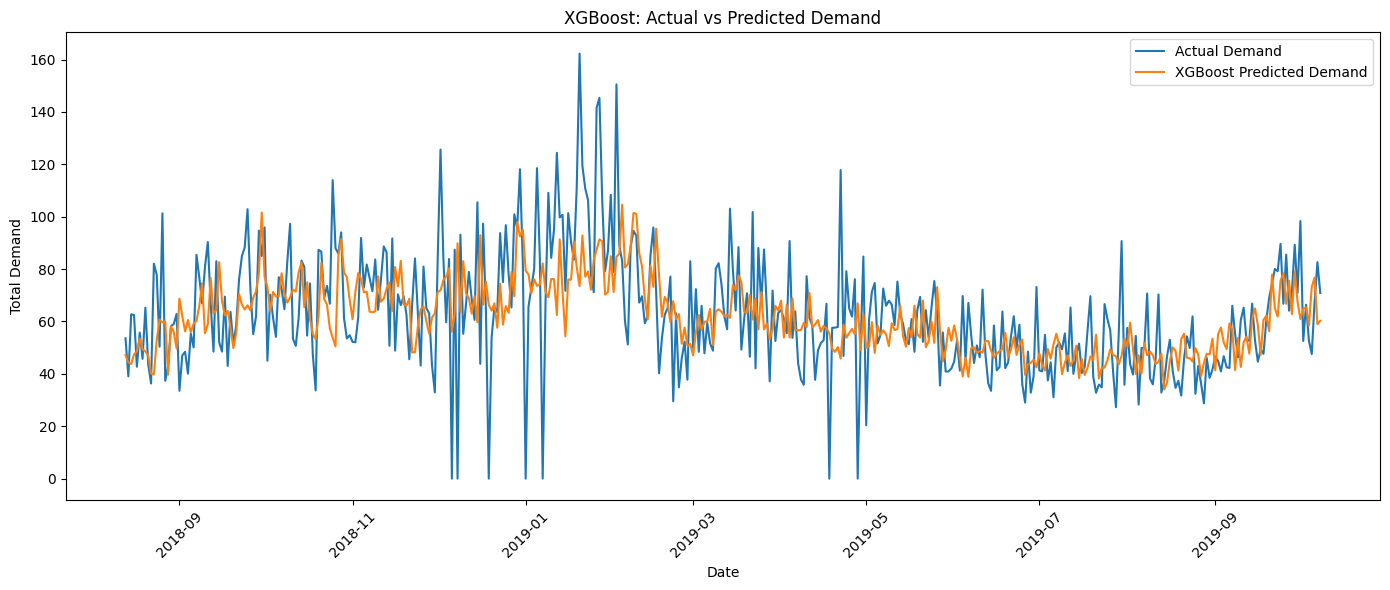

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    y_test.index,
    y_test.values,
    label="Actual Demand"
)

plt.plot(
    y_test.index,
    xgb_predictions,
    label="XGBoost Predicted Demand"
)

plt.title("XGBoost: Actual vs Predicted Demand")
plt.xlabel("Date")
plt.ylabel("Total Demand")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# XGBoost Feature Importance

XGBoost Feature Importance:


,Feature,Importance
0,rolling_mean_14,0.196191
1,rolling_mean_7,0.148034
2,month,0.084431
3,rolling_mean_30,0.080156
4,lag_7,0.072334
5,day_of_week,0.072036
6,year,0.069318
7,lag_14,0.063528
8,lag_3,0.055056
9,lag_30,0.055036


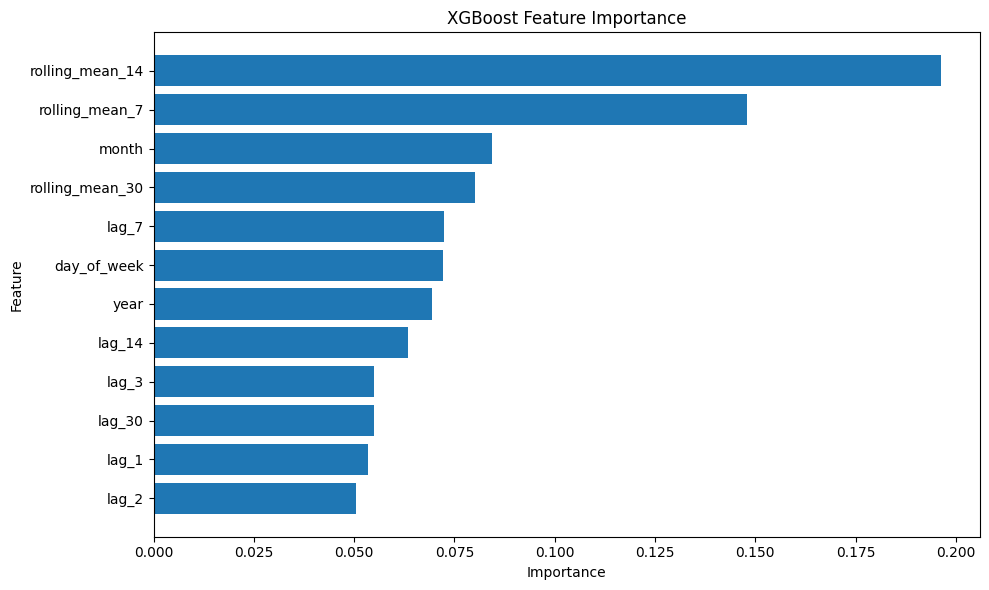

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

# Sort from highest to lowest
importance = importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print("XGBoost Feature Importance:")
display(importance)


# Plot feature importance
plt.figure(figsize=(10, 6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

# Highest importance at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
# Model Comparison Graph

In [56]:
comparison = pd.DataFrame({
    "Model": [
        "ARIMA(2,0,2)",
        "SARIMA(1,0,3)(1,0,1,7)",
        "XGBoost"
    ],
    "MAE": [
        17.9806,
        33.8193,
        xgb_mae
    ],
    "RMSE": [
        23.8047,
        39.2731,
        xgb_rmse
    ],
    "MAPE (%)": [
        27.4792,
        49.2277,
        xgb_mape
    ]
})

print("Final Model Comparison:")
display(comparison)

Final Model Comparison:


,Model,MAE,RMSE,MAPE (%)
0,"ARIMA(2,0,2)",17.980600,23.804700,27.479200
1,"SARIMA(1,0,3)(1,0,1,7)",33.819300,39.273100,49.227700
2,XGBoost,15.343004,20.786013,23.307984


In [ ]:
# Model Performance Comparison

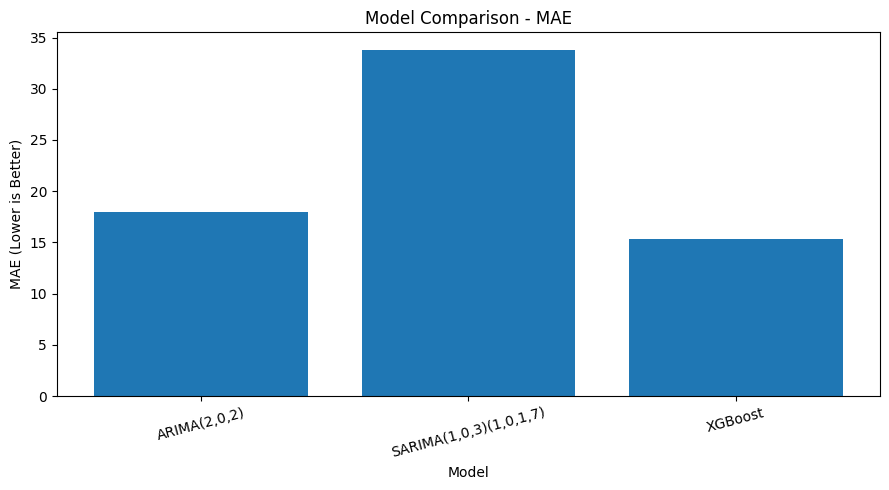

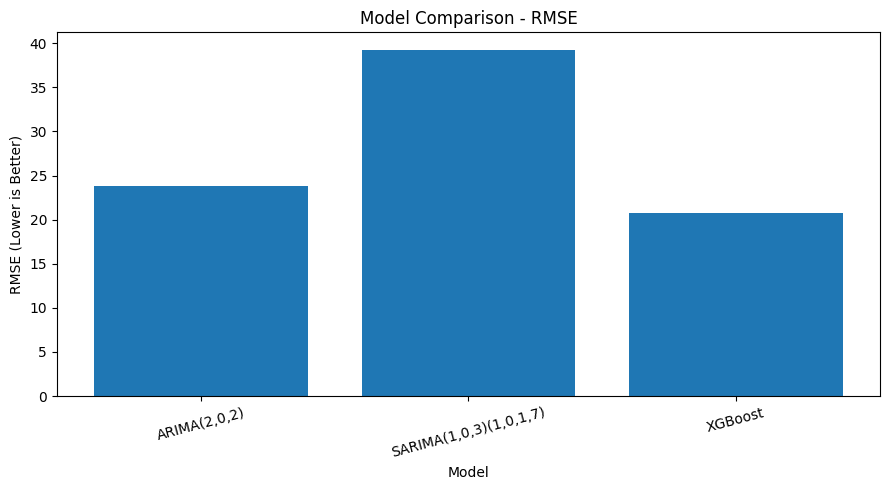

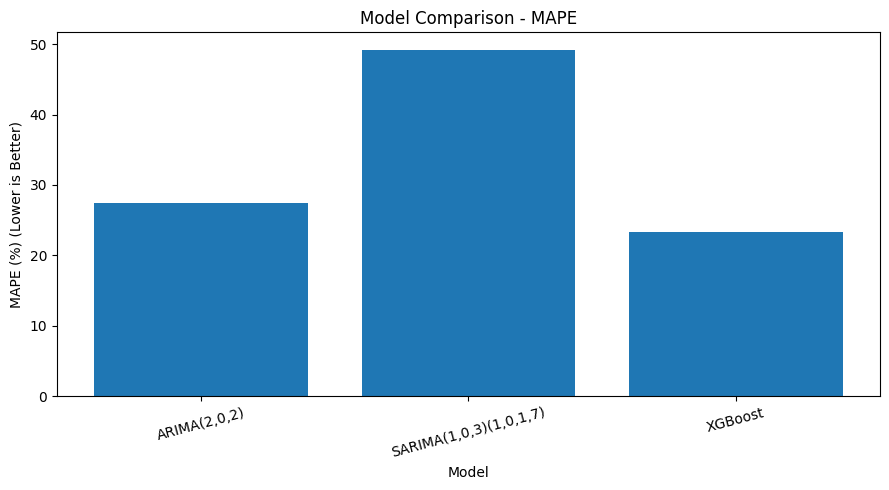

In [57]:

import matplotlib.pyplot as plt

# Plot MAE
plt.figure(figsize=(9, 5))

plt.bar(
    comparison["Model"],
    comparison["MAE"]
)

plt.title("Model Comparison - MAE")
plt.xlabel("Model")
plt.ylabel("MAE (Lower is Better)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


# Plot RMSE
plt.figure(figsize=(9, 5))

plt.bar(
    comparison["Model"],
    comparison["RMSE"]
)

plt.title("Model Comparison - RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE (Lower is Better)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


# Plot MAPE
plt.figure(figsize=(9, 5))

plt.bar(
    comparison["Model"],
    comparison["MAPE (%)"]
)

plt.title("Model Comparison - MAPE")
plt.xlabel("Model")
plt.ylabel("MAPE (%) (Lower is Better)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
# XGBoost Future Forecast

In [58]:
forecast_days = 30

# Copy the complete historical dataset
history = daily[["datum", "total_demand"]].copy()

history["datum"] = pd.to_datetime(history["datum"])
history = history.sort_values("datum")

# Keep only date and demand
history = history[["datum", "total_demand"]].reset_index(drop=True)

# Store future predictions
future_predictions = []

# Generate future dates
last_date = history["datum"].max()

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=forecast_days,
    freq="D"
)


for future_date in future_dates:

    # Current demand history
    demand_history = history["total_demand"]

    # Create features using only previous observations
    features_future = {
        "lag_1": demand_history.iloc[-1],
        "lag_2": demand_history.iloc[-2],
        "lag_3": demand_history.iloc[-3],
        "lag_7": demand_history.iloc[-7],
        "lag_14": demand_history.iloc[-14],
        "lag_30": demand_history.iloc[-30],

        "rolling_mean_7": demand_history.iloc[-7:].mean(),
        "rolling_mean_14": demand_history.iloc[-14:].mean(),
        "rolling_mean_30": demand_history.iloc[-30:].mean(),

        "day_of_week": future_date.dayofweek,
        "month": future_date.month,
        "year": future_date.year
    }

    # Create DataFrame with correct feature order
    future_X = pd.DataFrame(
        [features_future],
        columns=features
    )

    # Predict next day
    prediction = xgb_model.predict(future_X)[0]

    # Store prediction
    future_predictions.append(prediction)

    # Add predicted value to history
    # This allows the next day's lag features to use it
    history = pd.concat([
        history,
        pd.DataFrame({
            "datum": [future_date],
            "total_demand": [prediction]
        })
    ], ignore_index=True)



future_forecast = pd.DataFrame({
    "Date": future_dates,
    "Predicted_Demand": future_predictions
})

print("Future forecast generated successfully.")

display(future_forecast)

Future forecast generated successfully.


,Date,Predicted_Demand
0,2019-10-09,62.394520
1,2019-10-10,59.023369
2,2019-10-11,66.901192
3,2019-10-12,70.538383
4,2019-10-13,84.492401
5,2019-10-14,72.166916
6,2019-10-15,73.595665
7,2019-10-16,61.545055
8,2019-10-17,62.338005
9,2019-10-18,66.642281


In [ ]:
# Historical Demand + Future Forecast

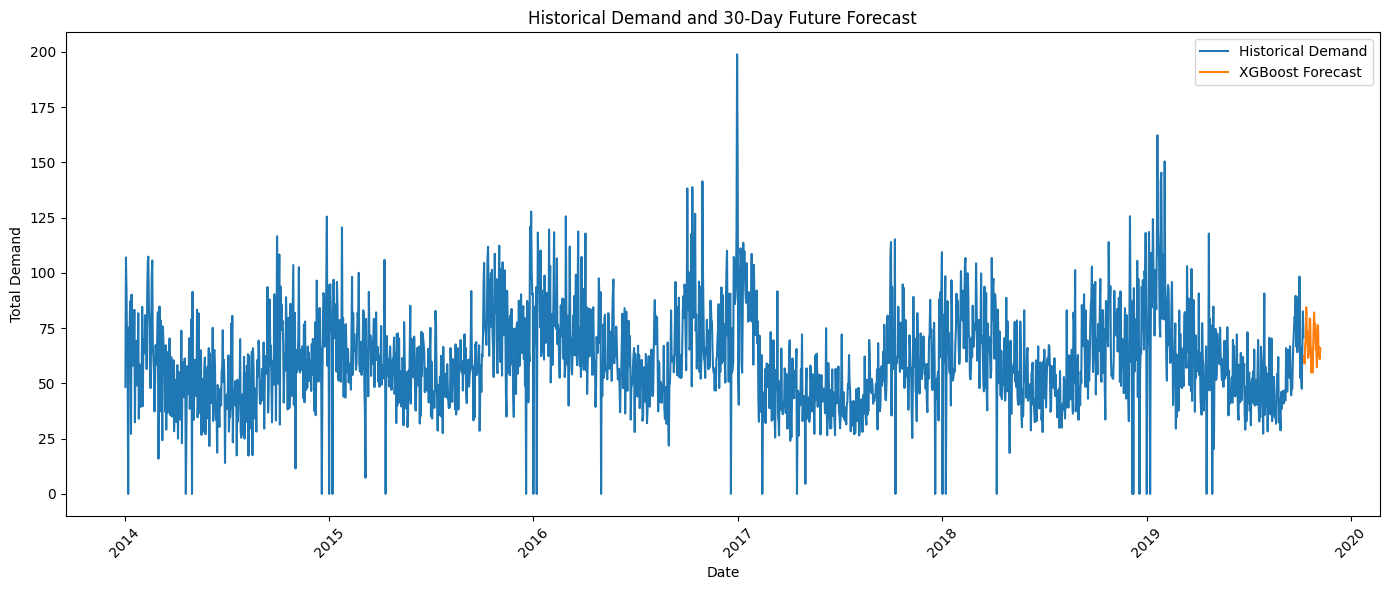

In [59]:

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Historical demand
plt.plot(
    daily["datum"],
    daily["total_demand"],
    label="Historical Demand"
)

# Future forecast
plt.plot(
    future_forecast["Date"],
    future_forecast["Predicted_Demand"],
    label="XGBoost Forecast"
)

plt.title("Historical Demand and 30-Day Future Forecast")
plt.xlabel("Date")
plt.ylabel("Total Demand")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# XGBoost Residual Analysis

In [60]:

# Calculate residuals
residuals = y_test.values - xgb_predictions

# Create residual dataframe
residual_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": xgb_predictions,
    "Residual": residuals
}, index=y_test.index)

print("Residual Summary:")
display(residual_df["Residual"].describe())

Residual Summary:


count    422.000000
mean       1.751227
std       20.736695
min      -89.866844
25%      -10.588491
50%        1.439424
75%       13.646912
max       88.754268
Name: Residual, dtype: float64

In [ ]:
# Residuals Over Time

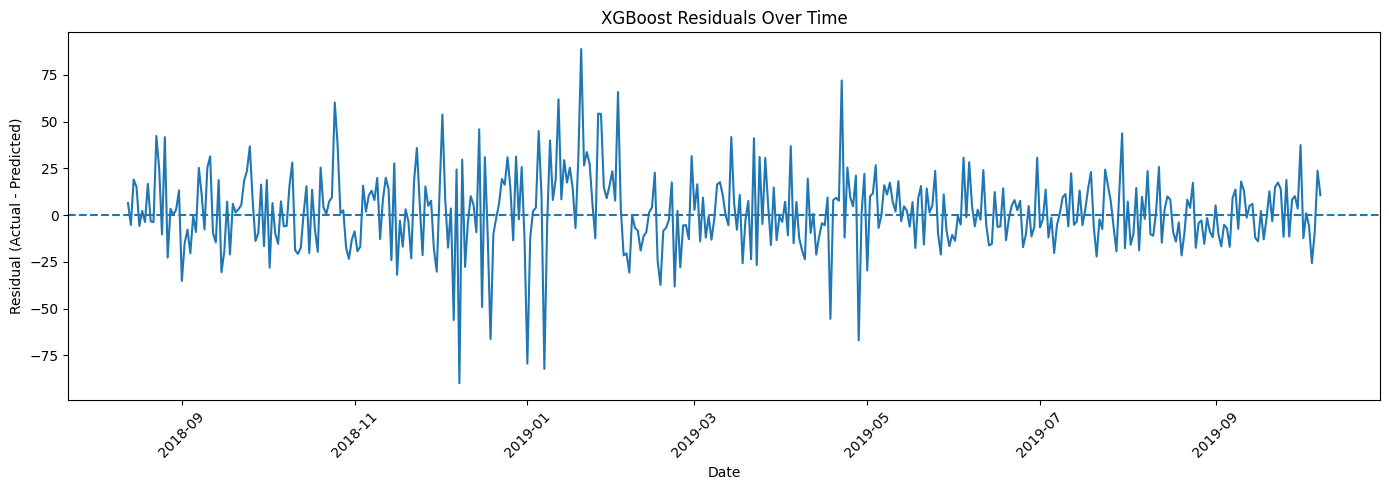

In [61]:

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    residual_df.index,
    residual_df["Residual"]
)

# Zero reference line
plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("XGBoost Residuals Over Time")
plt.xlabel("Date")
plt.ylabel("Residual (Actual - Predicted)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Findings

In [ ]:
1)The main finding from the project was that XGBoost performed better than the ARIMA and SARIMA models on the test data.

2)The rolling average features were particularly useful. The 14-day rolling average was the most important feature, followed by the 7-day rolling average. 
This shows that the recent demand level was useful for predicting future demand.

3)The model was able to follow the general demand pattern, although some sudden increases and decreases in demand were difficult to predict.

In [ ]:
# Business Recommendations

In [ ]:
1)Use the forecast as a support for inventory and demand planning.
2)Keep track of recent 7-day and 14-day demand because these were important for the model.
3)Consider weekly patterns when planning stock and resources.
4)Update and retrain the model when new demand data becomes available.
5)For better future predictions, include additional information such as holidays, promotions, pricing, and other external factors if available.

In [ ]:
# Final Conclusion

In [ ]:
1)I compared ARIMA, SARIMA, and XGBoost for pharmaceutical demand forecasting. 
2)After evaluating the models on the test dataset, XGBoost gave the lowest MAE, RMSE, and MAPE. 
3)I therefore selected XGBoost as the final model and used it to generate a 30-day future demand forecast. 
4)The project helped me understand how traditional time-series models and machine-learning models can be used for demand forecasting 
and how model performance can be compared using different error metrics.